# Quick Start (5 Minutes)

Let's run your first experiment and capture data in just a few steps!

This quick start uses **mock devices** (simulated hardware), so you don't need any physical equipment to follow along.

## What We'll Do

1. Set up a simple experiment environment
2. Run a scan that captures data
3. View the captured data
4. Export to CSV

Let's get started!

## Step 1: Import Required Modules

First, we'll import the Bluesky framework components:

In [1]:
import sys
from pathlib import Path

# Make sure we can import from parent directory
parent_dir = Path.cwd().parent if 'jupyter_book_tutorial' in str(Path.cwd()) else Path.cwd()
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Core Bluesky imports
from bluesky import RunEngine
from bluesky.callbacks.best_effort import BestEffortCallback
from ophyd import Signal
from bluesky.plans import scan

# Our custom components
from bluesky_config.devices import MockDetector
from bluesky_config.callbacks import DocumentLogger
from bluesky_config.metadata import create_experiment_metadata
from databroker import Broker

print("✓ All modules imported successfully!")

✓ All modules imported successfully!

## Step 2: Set Up the RunEngine

The RunEngine is the core component that executes experiments and manages data flow:

In [2]:
# Create the RunEngine
RE = RunEngine({})

# Add BestEffortCallback for live plotting and tables
bec = BestEffortCallback()
RE.subscribe(bec)

# Add DocumentLogger to save data to files (CRITICAL for data capture!)
doc_logger = DocumentLogger('../data/documents')
RE.subscribe(doc_logger)

# Also store in DataBroker for easy retrieval
db = Broker.named('temp')
RE.subscribe(db.v1.insert)

print("✓ RunEngine configured with data capture enabled")
print("  - Documents will be saved to: data/documents/")
print("  - Data accessible via DataBroker")

✓ RunEngine configured with data capture enabled

  - Documents will be saved to: data/documents/

  - Data accessible via DataBroker

```{important}
The **DocumentLogger** subscription is critical! Without it, your data won't be saved to disk.
```

## Step 3: Create Devices

We'll create a mock motor and detector:

In [3]:
# Create a simple motor (just a Signal for position)
motor = Signal(name='motor', value=0)

# Create a mock detector (simulates measurement data)
detector = MockDetector(name='det', noise_level=0.15)

print("✓ Devices created:")
print(f"  - Motor: {motor.name}")
print(f"  - Detector: {detector.name}")

✓ Devices created:

  - Motor: motor

  - Detector: det

## Step 4: Configure the Scan

Let's set up a simple scan from 0 to 10 with 20 points:

In [4]:
# Scan parameters
start = 0
stop = 10
num_points = 20

# Create metadata for this run
md = create_experiment_metadata(
    experiment_id='QUICKSTART-001',
    purpose='First data capture experiment',
    plan_type='scan',
    start=start,
    stop=stop,
    num_points=num_points,
)

print("✓ Scan configured:")
print(f"  - Range: {start} to {stop}")
print(f"  - Points: {num_points}")
print(f"  - Experiment ID: {md['experiment_id']}")

✓ Scan configured:

  - Range: 0 to 10

  - Points: 20

  - Experiment ID: QUICKSTART-001

## Step 5: Run the Experiment! 🚀

Now let's execute the scan and capture data:

Running scan...




Transient Scan ID: 1     Time: 2025-10-19 11:48:53

Persistent Unique Scan ID: '1aef708b-4745-4709-a2a9-5cb129c4972e'

📝 Logging documents to: 1aef708b_documents.jsonl

New stream: 'primary'

...

scan scan ['1aef708b'] (scan num: 1)

   Saved stop document


✓ Scan complete!


Run UID: 1aef708b-4745-4709-a2a9-5cb129c4972e

Short UID: 1aef708b

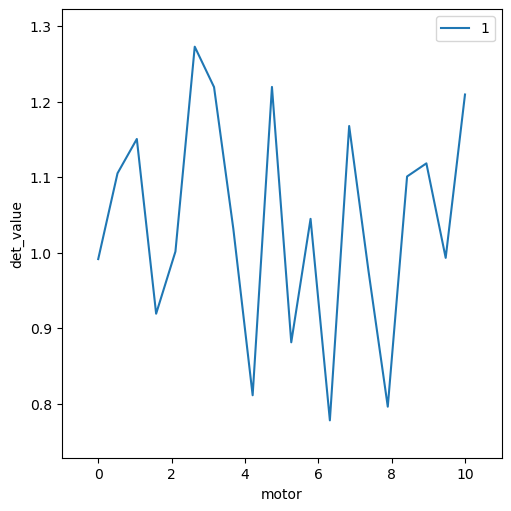

In [5]:
print("Running scan...\n")
print("=" * 70)

# Execute the scan
uid = RE(scan([detector], motor, start, stop, num_points), **md)

print("=" * 70)
print(f"\n✓ Scan complete!")
print(f"\nRun UID: {uid[0]}")
print(f"Short UID: {uid[0][:8]}")

```{tip}
The UID (Unique IDentifier) is how you'll refer to this run later. 
The short UID (first 8 characters) is usually sufficient.
```

## Step 6: Verify Data Was Captured

Let's check that data was actually saved:

In [6]:
# Check document file was created
doc_file = Path(f"../data/documents/{uid[0]}_documents.jsonl")

if doc_file.exists():
    print("✓ Document file created successfully!")
    print(f"  Location: {doc_file}")
    print(f"  Size: {doc_file.stat().st_size} bytes")
else:
    print("❌ Document file not found!")
    print("  Check that DocumentLogger was subscribed")

❌ Document file not found!

  Check that DocumentLogger was subscribed

## Step 7: Retrieve and View the Data

Now let's load the data and look at it:

In [7]:
# Get the run from DataBroker
run = db[-1]  # Get the most recent run

# Convert to pandas DataFrame
table = run.table()

print("✓ Data loaded successfully!\n")
print(f"Data shape: {table.shape[0]} rows × {table.shape[1]} columns")
print(f"\nColumns: {list(table.columns)}")
print(f"\nFirst few rows:")
print(table.head())

✓ Data loaded successfully!


Data shape: 20 rows × 3 columns


Columns: ['time', 'det_value', 'motor']


First few rows:

                                 time  det_value     motor
seq_num                                                   
1       2025-10-19 15:48:53.635546207   0.991327  0.000000
2       2025-10-19 15:48:53.677386045   1.104958  0.526316
3       2025-10-19 15:48:53.706207991   1.150375  1.052632
4       2025-10-19 15:48:53.734220028   0.918966  1.578947
5       2025-10-19 15:48:53.762748003   1.001324  2.105263

## Step 8: View Basic Statistics

In [8]:
import pandas as pd

print("Data Statistics:")
print("=" * 50)
print(table[['motor', 'det_value']].describe())

Data Statistics:

           motor  det_value
count  20.000000  20.000000
mean    5.000000   1.039195
std     3.113726   0.148760
min     0.000000   0.777748
25%     2.500000   0.961592
50%     5.000000   1.037917
75%     7.500000   1.154673
max    10.000000   1.272585

## Step 9: Plot the Data

Let's visualize what we captured:

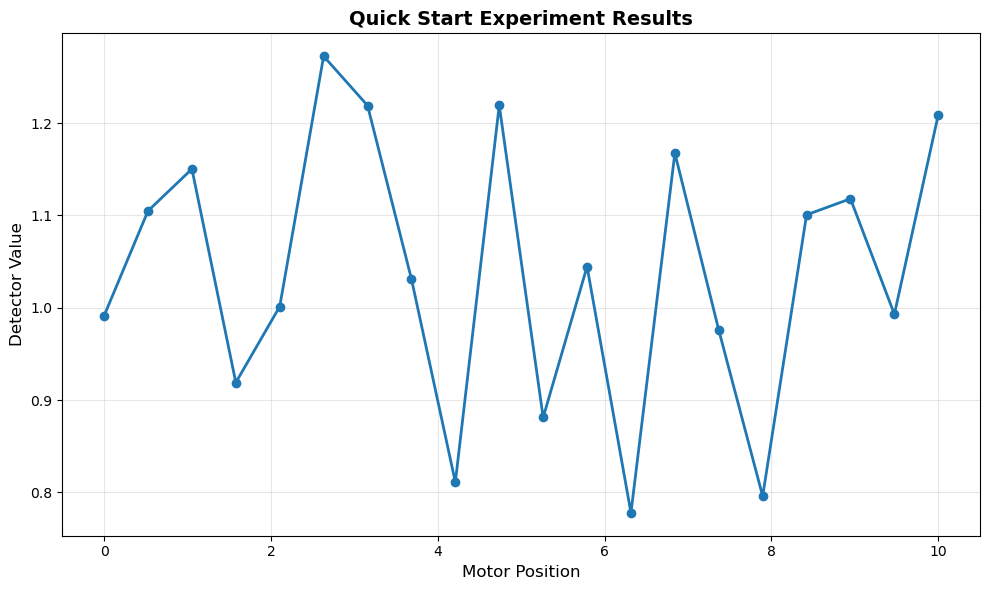

✓ Plot created!

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(table['motor'], table['det_value'], 'o-', linewidth=2, markersize=6)
ax.set_xlabel('Motor Position', fontsize=12)
ax.set_ylabel('Detector Value', fontsize=12)
ax.set_title('Quick Start Experiment Results', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Plot created!")

## Step 10: Export to CSV

Finally, let's export the data to a CSV file:

In [10]:
from analysis.export import export_to_csv

# Export to CSV
export_path = f"../data/exports/quickstart_{uid[0][:8]}.csv"
export_to_csv(run, export_path)

print(f"✓ Data exported to: {export_path}")
print(f"\nYou can now open this file in Excel, Python, or any CSV reader.")

AttributeError: 'Header' object has no attribute 'metadata'

## Congratulations! 🎉

You've successfully:

✅ Set up a Bluesky experiment environment  
✅ Run a scan with data capture enabled  
✅ Verified data was saved  
✅ Retrieved and viewed the data  
✅ Created a plot  
✅ Exported to CSV  

## What Just Happened?

Behind the scenes:

1. **RunEngine** executed the scan plan
2. For each of 20 points:
   - Motor moved to position
   - Detector took a reading
   - Data was recorded as an "event"
3. **DocumentLogger** saved everything to disk
4. **DataBroker** indexed the run for easy retrieval
5. You retrieved and analyzed the captured data

## Key Takeaways

```{important}
**Essential Pattern for Data Capture:**
1. Create RunEngine
2. Subscribe DocumentLogger: `RE.subscribe(DocumentLogger('path'))`
3. Run experiment: `RE(plan, **metadata)`
4. Data is automatically saved!
```

## Next Steps

Now that you've captured your first data, you can:

- **Chapter 2**: Learn the four different methods for running experiments
- **Chapter 3**: Understand what data gets captured in detail
- **Chapter 6**: Try more complex practical examples

Or jump directly to [Practical Examples](06_practical_examples.ipynb) to see real-world scenarios!

## Try It Yourself

Before moving on, try modifying the experiment:

**Challenge 1**: Change the scan range to 0-20 with 50 points

**Challenge 2**: Change the detector noise level to 0.5

**Challenge 3**: Add a second detector and scan both

Simply edit the code cells above and re-run them to see the effects!